# Building the MySQL connection with Python and importing all your data to MySQL Database

In [ ]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments'),
    ('order_items.csv', 'order_items') # Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Mayuresh@123',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = 'D:/Yess Infotech/Data Analytics/Python/Projects/Ecommerce\Dataset'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64



In [89]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import mysql.connector
import os

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Mayuresh@123',
    database='ecommerce'
)
cursor = conn.cursor()

In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


# List all unique cities where customers are located

In [3]:
query = "SELECT DISTINCT customer_city FROM customers"

cursor.execute(query)

# fetchall() returns a list of tuples, e.g., [('New York',), ('London',)]
data = cursor.fetchall()

data

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

In [4]:
# Re-establishingthe MySQL Connection.
import mysql.connector

# Re-establish the connection (No data will be imported, we're just 'logging in')
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Mayuresh@123',
    database='ecommerce'
)

# Re-create the cursor
cursor = conn.cursor()

# List all unique cities where customers are located 

In [5]:
query = "SELECT DISTINCT customer_city FROM customers"

cursor.execute(query)

data = cursor.fetchall()

df = pd.DataFrame(data)
df.head()

,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


# Count the number of orders placed in 2017

In [6]:
query = """ select count(order_id) from orders where year(order_purchase_timestamp) = 2017 """

cursor.execute(query)

data = cursor.fetchall()

print(f"Total orders placed in 2017 are {data[0][0]}")

Total orders placed in 2017 are 45101


# Find the total  sales per category

In [75]:
query = """ select upper(products.product_category) category, 
round(sum(payments.payment_value), 2) sales
from products join order_items
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by category
"""

cursor.execute(query)
data = cursor.fetchall()

df = pd.DataFrame(data, columns =  ["category", "sales"])
df

,category,sales
0,PERFUMERY,506738.66
1,FURNITURE DECORATION,1430176.39
2,TELEPHONY,486882.05
3,BED TABLE BATH,1712553.67
4,AUTOMOTIVE,852294.33
...,...,...
69,CDS MUSIC DVDS,1199.43
70,LA CUISINE,2913.53
71,FASHION CHILDREN'S CLOTHING,785.67
72,PC GAMER,2174.43


# Calculate the prcentage of orders that were paid in installaments

In [8]:
query = """ 
SELECT (SUM(CASE WHEN payment_installments > 1 THEN 1 ELSE 0 END)) / COUNT(*)*100 
FROM payments
"""

cursor.execute(query) 

data = cursor.fetchall()

# Display result
"Calculate the prcentage of orders that were paid in installaments", data[0][0]

('Calculate the prcentage of orders that were paid in installaments',
 Decimal('49.4176'))

# Count the number  of customers from each state

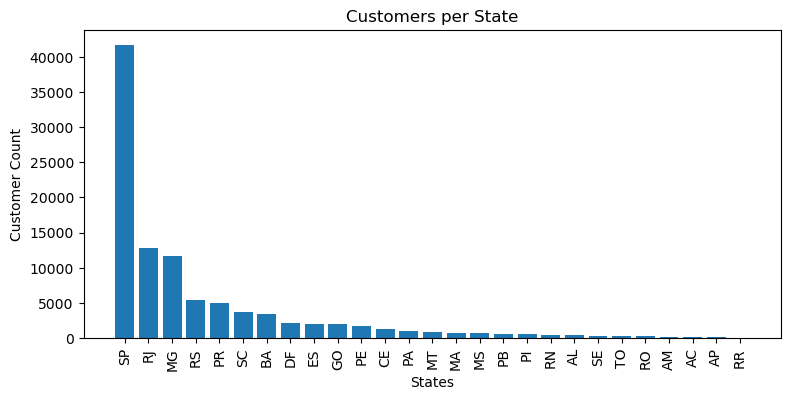

In [31]:
import matplotlib.pyplot as plt

query = """ 
select customer_state, count(customer_id)
from customers group by customer_state
"""

cursor.execute(query) 

data = cursor.fetchall()

# 1. Ensure columns match the SQL output
df = pd.DataFrame(data, columns = ["state", "customer_count"])
df = df.sort_values(by = "customer_count", ascending= False)

# 2. Set figure size so x-axis labels are readable
plt.figure(figsize=(9, 4))

# 3. Create the bar chart
plt.bar(df["state"], df["customer_count"])

# 4. Add labels for clarity
plt.xlabel("States")
plt.ylabel("Customer Count")
plt.title("Customers per State")
plt.xticks(rotation = 90)
plt.show()

# Calculate the number of orders per month in 2018

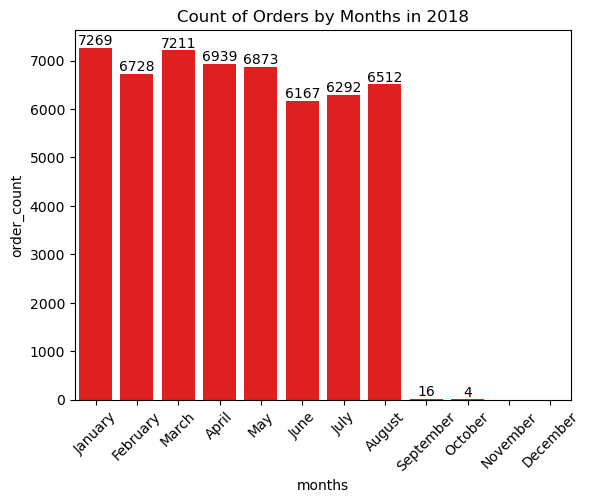

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

query = """
select monthname(order_purchase_timestamp) as months, count(order_id) as order_count
from orders
where year(order_purchase_timestamp) = 2018
group by monthname(order_purchase_timestamp)
"""

cursor.execute(query)

data = cursor.fetchall()

df = pd.DataFrame(data, columns=["months", "order_count"])

o = ["January", "February", "March", "April", "May", "June",
     "July", "August", "September", "October", "November", "December"]

ax = sns.barplot(x = df["months"], y = df["order_count"], order = o, color = "Red")
plt.xticks(rotation = 45)
ax.bar_label(ax.containers[0])
plt.title("Count of Orders by Months in 2018")

plt.show()

In [ ]:
# Find the average number of products per order, grouped by customer city

In [91]:
query = """
with count_per_order as
(
select orders.order_id,
       orders.customer_id,
       count(order_items.order_id) as oc
from orders
join order_items
on orders.order_id = order_items.order_id
group by orders.order_id, orders.customer_id
)

select customers.customer_city,
       round(avg(count_per_order.oc), 2) as average_orders
from customers
join count_per_order
on customers.customer_id = count_per_order.customer_id
group by customers.customer_city
order by average_orders desc
"""

cursor.execute(query)

data = cursor.fetchall()

df = pd.DataFrame(data, columns=["customer_city", "average_orders"])

df.head(10)

,customer_city,average_orders
0,padre carvalho,7.00
1,celso ramos,6.50
2,datas,6.00
3,candido godoi,6.00
4,matias olimpio,5.00
5,cidelandia,4.00
6,picarra,4.00
7,morro de sao paulo,4.00
8,teixeira soares,4.00
9,curralinho,4.00


# Calculatethe the percentage of total revenue contributed by each product category

In [101]:
query = """select upper(products.product_category) category, 
round((sum(payments.payment_value) / (select sum(payment_value) from payments)) * 100, 2) sales_percentage
from products join order_items
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by category
order by sales_percentage desc
"""

cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns=["category", "percentage distribution"])
df.head()

,category,percentage distribution
0,BED TABLE BATH,10.70
1,HEALTH BEAUTY,10.35
2,COMPUTER ACCESSORIES,9.90
3,FURNITURE DECORATION,8.93
4,WATCHES PRESENT,8.93


# Re-establishing the MySQL connection with Python

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import mysql.connector
import os

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Mayuresh@123',
    database='ecommerce'
)
cursor = conn.cursor()

# Identify the correlation between product price  and the number of tiems the product has been purchased

In [110]:
import numpy as np
import pandas as pd

query = """select products.product_category,
count(order_items.product_id),
round(avg(order_items.price), 2)
from products join order_items
on products.product_id = order_items.product_id
group by products.product_category;
"""

cursor.execute(query)
data = cursor.fetchall()

df = pd.DataFrame(data, columns=["category", "order_count", "price"])

arr1 = df["order_count"]
arr2 = df["price"]

a = np.corrcoef(arr1, arr2)
print("The correlation between the price and the number of times the product has been purchased is", a[0][-1])

The correlation between the price and the number of times the product has been purchased is -0.10631514167157562


# Calculate the  total revenue generated by each seller, and rank by revenue

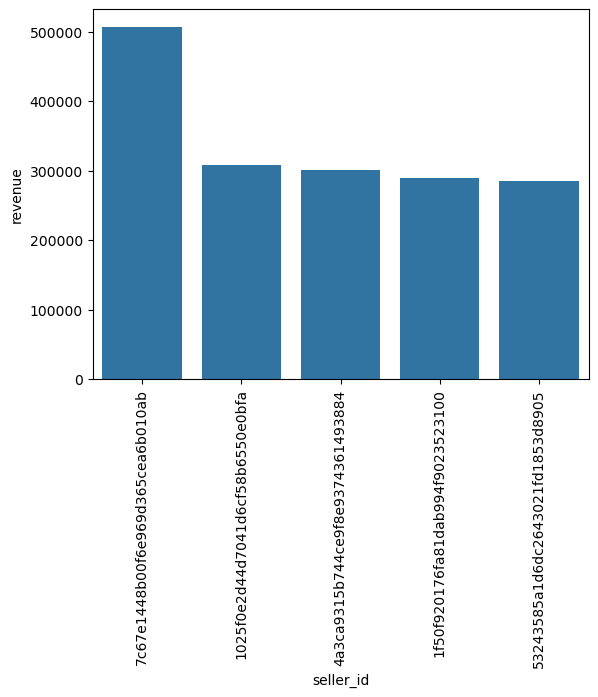

In [127]:
query = """ select *, dense_rank() over (order by revenue desc) as rn from
(select order_items.seller_id, sum(payments.payment_value)
revenue from order_items join payments
on order_items.order_id = payments.order_id
group by order_items.seller_id) as a
"""

cursor.execute(query)
data = cursor.fetchall()
df =  pd.DataFrame(data, columns = ["seller_id", "revenue", "rank"])
df = df.head()
df.head()

sns.barplot(x = "seller_id", y = "revenue", data = df)
plt.xticks(rotation = 90)
plt.show()

# Calculate  the moving average of order values for each customer over their order history

In [129]:
query = """ select customer_id, order_purchase_timestamp, payment,
avg(payment) over(partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row) as mov_avg
from
(select orders.customer_id, orders.order_purchase_timestamp,
payments.payment_value  as payment
from payments join orders
on payments.order_id = orders.order_id) as a;
"""
cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns=["customer_id", "order_purchase_timestamp", "payment", "mov_avg"])
df

,customer_id,order_purchase_timestamp,payment,mov_avg
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002
...,...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,71.23,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.13,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000


# Calculate the cumulative sales per month for each year

In [130]:
query = """ select years, months, payment, sum(payment)
over(order by years, months) cumulative_sales from
(select year(orders.order_purchase_timestamp) as years,
month(orders.order_purchase_timestamp) as months,
round(sum(payments.payment_value), 2) as payment from orders join payments 
on orders.order_id = payments.order_id
group by years, months order by years, months) as a;
"""
cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns=["customer_id", "order_purchase_timestamp", "payment", "mov_avg"])
df

,customer_id,order_purchase_timestamp,payment,mov_avg
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,197850.38
4,2017,2,291908.01,489758.39
5,2017,3,449863.60,939621.99
6,2017,4,417788.03,1357410.02
7,2017,5,592918.82,1950328.84
8,2017,6,511276.38,2461605.22
9,2017,7,592382.92,3053988.14


# Visual presentation of cumulative sales on the basis os month and year

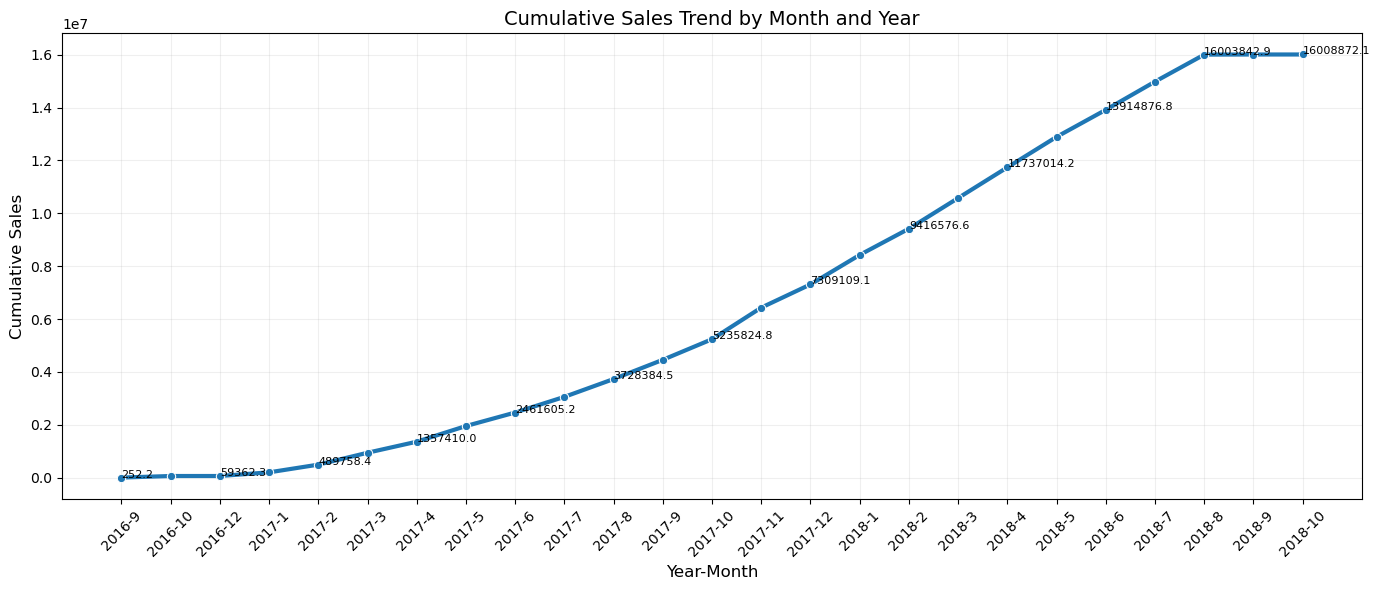

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

query = """ 
select years, months, payment, 
sum(payment) over(order by years, months) as cumulative_sales
from
(
select year(orders.order_purchase_timestamp) as years,
       month(orders.order_purchase_timestamp) as months,
       round(sum(payments.payment_value), 2) as payment
from orders 
join payments 
on orders.order_id = payments.order_id
group by years, months
order by years, months
) as a;
"""

cursor.execute(query)

data = cursor.fetchall()

df = pd.DataFrame(data, columns=["years", "months", "payment", "cumulative_sales"])

df["year_month"] = df["years"].astype(str) + "-" + df["months"].astype(str)

plt.figure(figsize=(14,6))

ax = sns.lineplot(
    x="year_month",
    y="cumulative_sales",
    data=df,
    marker="o",
    linewidth=3
)

plt.xticks(rotation=45)

plt.title("Cumulative Sales Trend by Month and Year", fontsize=14)
plt.xlabel("Year-Month", fontsize=12)
plt.ylabel("Cumulative Sales", fontsize=12)

# light grid only
plt.grid(alpha=0.2)

# only alternate labels to avoid overlap
for i, value in enumerate(df["cumulative_sales"]):
    if i % 2 == 0:
        plt.text(i, value, round(value, 1), fontsize=8)

plt.tight_layout()

plt.show()

# Calculate the year-over-year-growth rate for total sales

In [144]:
query = """ with a as (select year(orders.order_purchase_timestamp) as years,
round(sum(payments.payment_value), 2) as payment from orders join payments 
on orders.order_id = payments.order_id
group by years order by years)

select years, ((payment - lag(payment, 1) over(order by years)) / lag(payment, 1) over(order by years)) * 100 from a
"""

cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns = ["years", "yoy % growth"])
df

,years,yoy % growth
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


# Calculate the retention rate  of customers, defined as thepercentage of customers who make another purchase within 6 months

In [145]:
# Note: Since none of our customers have repeated, our value is null
query = """ with a as(select customers.customer_id,
min(orders.order_purchase_timestamp) first_order
from customers join orders
on customers.customer_id = orders.customer_id
group by customers.customer_id),
b as (select a.customer_id, count(distinct orders.order_purchase_timestamp)
from a join orders
on orders.customer_id = a.customer_id
and orders.order_purchase_timestamp > first_order
and orders.order_purchase_timestamp < date_add(first_order, interval 6 month)
group by a.customer_id)
select 100 * (count(distinct a.customer_id) / count(distinct b.customer_id))
from a left join b
on a.customer_id = b.customer_id;
"""

cursor.execute(query)
data = cursor.fetchall()

data

[(None,)]

# Identify the top 3 customers who spent the most money in each year

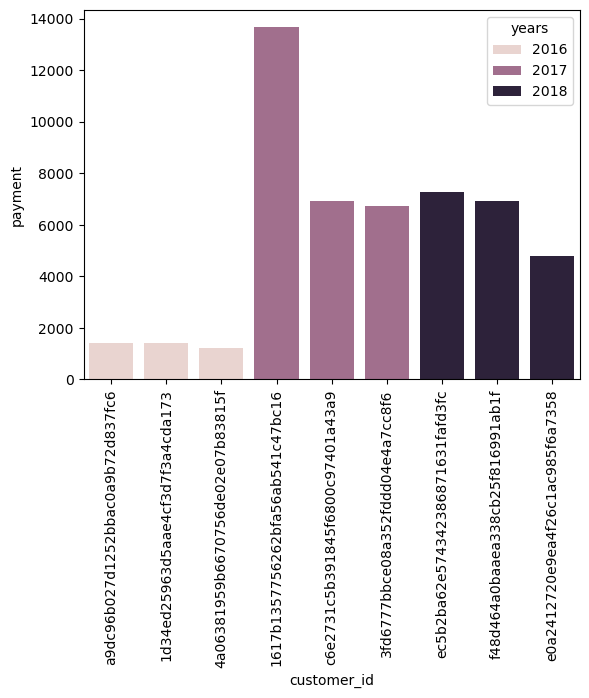

In [148]:
query = """ select years,customer_id, payment, d_rank
from
(select year(orders.order_purchase_timestamp) years,
orders.customer_id,
sum(payments.payment_value) payment,
dense_rank() over(partition by year(orders.order_purchase_timestamp)
order by sum(payments.payment_value) desc) d_rank
from orders join payments
on payments.order_id = orders.order_id
group by year(orders.order_purchase_timestamp),
orders.customer_id) as a
where d_rank <= 3;
"""

cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns = ["years", "customer_id", "payment", "rank"])
sns.barplot(x = "customer_id", y = "payment", data = df, hue = "years")
plt.xticks(rotation = 90)
plt.show()